# NB_02 · Analyse Exploratoire des Données (EDA)

### Prédiction des annulations de réservations hôtelières

## Objectif du notebook

Ce notebook est consacré à l'analyse exploratoire des données (Exploratory Data Analysis – EDA).

L'objectif est de comprendre la structure, la qualité et les caractéristiques du jeu de données afin de justifier les choix de prétraitement qui seront réalisés dans le notebook suivant.

Les analyses portent notamment sur :

- la qualité des données ;
- les valeurs manquantes ;
- les doublons ;
- les statistiques descriptives ;
- les distributions des variables ;
- les valeurs aberrantes ;
- les corrélations ;
- les relations entre les variables explicatives et la variable cible.


# 1. Aperçu général du jeu de données

Cette première exploration permet de vérifier que le jeu de données a été correctement chargé et d'obtenir une vue d'ensemble de sa structure.

Les informations affichées permettent notamment d'identifier :

- le nombre d'observations et de variables ;
- les types de données (numériques et catégorielles) ;
- les premières statistiques descriptives des variables numériques.

In [52]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

RAW_FILE = PROJECT_ROOT / "data" / "raw" / "hotel_bookings_raw.csv"

df = pd.read_csv(RAW_FILE)

print(df.shape)

display(df.head())

df.info()


(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Interprétation

Les statistiques descriptives montrent que les variables numériques présentent des comportements variés.

Certaines variables, comme `lead_time` (0 à 737 jours) ou `days_in_waiting_list` (0 à 391 jours), possèdent une grande dispersion, ce qui traduit une forte variabilité des réservations.

La variable `adr` (Average Daily Rate) présente une valeur minimale négative (-6,38) ainsi qu'une valeur maximale très élevée (5400), ce qui laisse supposer la présence de valeurs aberrantes.

De même, les variables `adults`, `children`, `babies` et `stays_in_week_nights` comportent des valeurs maximales très éloignées de la médiane, ce qui nécessite une analyse spécifique des valeurs extrêmes.

Ces statistiques descriptives constituent une première étape d'exploration et orientent les analyses qui seront réalisées dans la section consacrée aux valeurs aberrantes.

### Décision

Les statistiques descriptives ont permis d'identifier plusieurs variables susceptibles de contenir des valeurs aberrantes.

Ces variables feront l'objet d'une analyse approfondie à l'aide des Boxplots (basés sur l'IQR) afin de déterminer si ces observations correspondent à des erreurs de données ou à des cas réels du domaine hôtelier.

# 2. Qualité des données

Cette étape permet d'identifier les éventuelles anomalies susceptibles d'influencer les analyses statistiques ou les performances des modèles prédictifs.

Les principaux éléments étudiés sont :

- les valeurs manquantes ;
- les valeurs codées différemment (NA, espaces, 999...) ;
- les doublons.

## 2.1 Valeurs manquantes

In [53]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'valeurs_manquantes': missing, 'pourcentage_%': missing_pct})
missing_summary = missing_summary[missing_summary['valeurs_manquantes'] > 0].sort_values('pourcentage_%', ascending=False)
missing_summary


,valeurs_manquantes,pourcentage_%
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


C:\Users\fatma\AppData\Local\Temp\ipykernel_40972\2636093092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_summary.index, y=missing_summary['pourcentage_%'], palette='Reds_r')


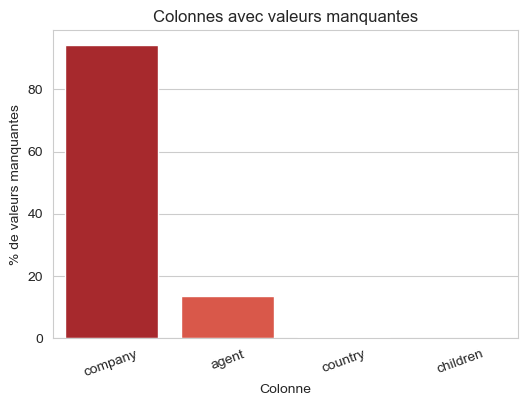

In [54]:
plt.figure(figsize=(6,4))
sns.barplot(x=missing_summary.index, y=missing_summary['pourcentage_%'], palette='Reds_r')
plt.ylabel('% de valeurs manquantes')
plt.xlabel('Colonne')
plt.title('Colonnes avec valeurs manquantes')
plt.xticks(rotation=20)
plt.show()


### Interprétation

L'analyse des valeurs manquantes montre que seules quatre variables sont concernées : `company`, `agent`, `country` et `children`.

Les variables `company` et `agent` présentent la plus forte proportion de valeurs manquantes. Cette situation est cohérente avec le contexte métier, car de nombreuses réservations sont effectuées directement par les clients, sans passer par une entreprise ou un agent de voyage.

À l'inverse, `country` et `children` contiennent très peu de valeurs manquantes. Leur traitement sera donc relativement simple lors du prétraitement.

### Décision

Les valeurs manquantes ne seront pas traitées durant cette phase.

L'EDA a pour objectif de les identifier et de comprendre leur origine.

Le choix de la méthode d'imputation sera justifié dans le Notebook 03 consacré au prétraitement.

## 2.2 Recherche d'autres représentations des valeurs manquantes

Certaines bases de données utilisent d'autres représentations que `NaN` pour coder les valeurs manquantes (par exemple des espaces vides, la chaîne `"NA"` ou la valeur `999`).

Cette vérification permet de détecter ces cas avant le prétraitement.

In [55]:
# Recherche d'autres représentations de valeurs manquantes

empty_values = (
    df.select_dtypes(include="object")
      .apply(lambda x: x.astype(str).str.strip().eq("").sum())
)

na_values = (
    df.select_dtypes(include="object")
      .apply(lambda x: x.astype(str).str.upper().eq("NA").sum())
)

code999 = (df == 999).sum()

print(f"Valeurs vides : {empty_values.sum()}")
print(f"Valeurs 'NA' : {na_values.sum()}")
print(f"Valeurs codées 999 : {code999.sum()}")

Valeurs vides : 0
Valeurs 'NA' : 0
Valeurs codées 999 : 0


### Interprétation

Aucune valeur manquante codée sous forme d'espaces, de la chaîne `"NA"` ou de la valeur `999` n'a été détectée.

Les valeurs manquantes présentes dans le jeu de données correspondent donc uniquement à de véritables valeurs `NaN`.

### Décision

Les traitements d'imputation porteront uniquement sur les valeurs `NaN` identifiées dans les variables concernées. Aucune conversion supplémentaire de valeurs codées n'est nécessaire.

## 2.3 Doublons

Les doublons correspondent à des observations identiques présentes plusieurs fois dans le jeu de données. Leur présence peut biaiser les analyses statistiques et influencer les performances des modèles d'apprentissage automatique.

Cette étape consiste à mesurer leur importance avant de décider du traitement à appliquer lors du prétraitement.

In [56]:
n_dup = df.duplicated().sum()
print(f"Lignes dupliquées : {n_dup} ({n_dup/len(df)*100:.2f}% du dataset)")


Lignes dupliquées : 31994 (26.80% du dataset)


### Interprétation

Le jeu de données contient **31 994 lignes dupliquées**, soit environ **26,8 %** des observations.

Cette proportion est importante. Toutefois, dans un contexte hôtelier, une réservation identique peut correspondre à plusieurs clients ayant effectué des réservations présentant exactement les mêmes caractéristiques. Ces doublons ne sont donc pas nécessairement des erreurs de saisie.

Une analyse plus approfondie sera réalisée lors du prétraitement afin de déterminer s'il s'agit de véritables doublons techniques ou d'observations légitimes.

### Décision

Les doublons ne seront pas supprimés automatiquement durant l'EDA.

Leur traitement sera effectué dans le Notebook 03 après analyse de leur impact sur la qualité des données et sur les performances des modèles prédictifs.

# 3. Analyse descriptive

L'analyse descriptive permet d'obtenir une première compréhension des caractéristiques du jeu de données.

Elle met en évidence les tendances générales, la dispersion des variables numériques ainsi que la répartition des variables catégorielles. Cette étape constitue également une première indication de la présence éventuelle de valeurs aberrantes.

## 3.1 Variables numériques

Les statistiques descriptives permettent de résumer le comportement des variables numériques à l'aide d'indicateurs tels que la moyenne, la médiane, l'écart-type, les valeurs minimales et maximales ainsi que les quartiles.

Ces informations facilitent l'identification des variables présentant une forte dispersion ou des valeurs potentiellement atypiques.

In [57]:
num_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'adr',
    'booking_changes',
    'days_in_waiting_list',
    'previous_cancellations',
    'total_of_special_requests'
]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0


### Interprétation

Les statistiques descriptives montrent que plusieurs variables présentent une forte variabilité.

Par exemple, `lead_time` atteint jusqu'à **737 jours**, ce qui reste plausible puisqu'une réservation peut être effectuée longtemps à l'avance. En revanche, certaines variables comme `adr` présentent des valeurs très élevées ou négatives, ce qui suggère la présence de valeurs aberrantes qui devront être analysées plus en détail.

Ces observations justifient la réalisation d'une analyse spécifique des outliers dans la section suivante.

### Décision

Les statistiques descriptives seront utilisées comme référence pour identifier les variables nécessitant un traitement particulier lors du prétraitement, notamment en ce qui concerne les valeurs aberrantes et les transformations éventuelles.

## 3.2 Variables catégorielles

Les variables catégorielles décrivent des caractéristiques qualitatives des réservations, telles que le type d'hôtel, le pays d'origine, le segment de marché ou le type de repas.

Leur analyse permet d'identifier le nombre de modalités de chaque variable et de préparer le choix des techniques d'encodage qui seront appliquées lors du prétraitement.

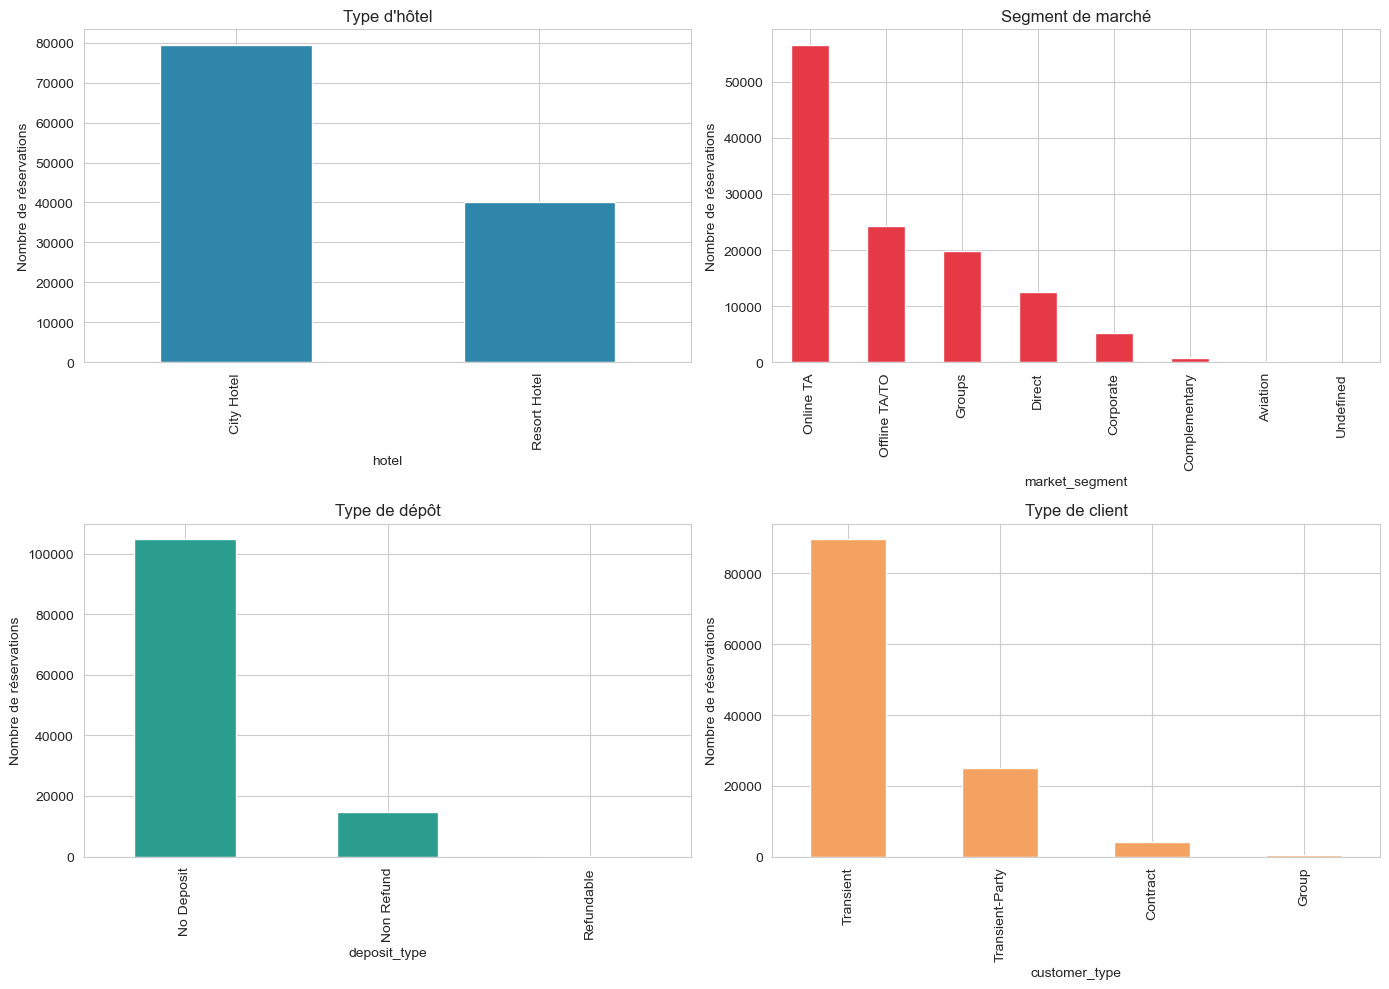

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

df['hotel'].value_counts().plot(kind='bar', ax=axes[0,0], color='#2E86AB')
axes[0,0].set_title("Type d'hôtel")
axes[0,0].set_ylabel("Nombre de réservations")

df['market_segment'].value_counts().plot(kind='bar', ax=axes[0,1], color='#E63946')
axes[0,1].set_title('Segment de marché')
axes[0,1].set_ylabel("Nombre de réservations")

df['deposit_type'].value_counts().plot(kind='bar', ax=axes[1,0], color='#2A9D8F')
axes[1,0].set_title('Type de dépôt')
axes[1,0].set_ylabel("Nombre de réservations")

df['customer_type'].value_counts().plot(kind='bar', ax=axes[1,1], color='#F4A261')
axes[1,1].set_title('Type de client')
axes[1,1].set_ylabel("Nombre de réservations")

plt.tight_layout()
plt.show()

In [59]:
print("Taux d'annulation par hôtel (%) :\n", (df.groupby('hotel')['is_canceled'].mean()*100).round(2))
print("\nTaux d'annulation par dépôt (%) :\n", (df.groupby('deposit_type')['is_canceled'].mean()*100).round(2))


Taux d'annulation par hôtel (%) :
 hotel
City Hotel      41.73
Resort Hotel    27.76
Name: is_canceled, dtype: float64

Taux d'annulation par dépôt (%) :
 deposit_type
No Deposit    28.38
Non Refund    99.36
Refundable    22.22
Name: is_canceled, dtype: float64


### Interprétation

Les graphiques montrent que les **City Hotels** représentent la majorité des réservations et que le segment **Online TA** constitue le principal canal de réservation. La plupart des clients effectuent leurs réservations **sans dépôt** et appartiennent au type **Transient**.

L'analyse des taux d'annulation apporte une information complémentaire. Les **City Hotels** présentent un taux d'annulation d'environ **41,7 %**, contre **27,8 %** pour les **Resort Hotels**. Les réservations effectuées dans les hôtels urbains semblent donc davantage sujettes aux annulations.

Le type de dépôt influence également fortement les annulations. Les réservations **Non Refund** affichent un taux d'annulation proche de **100 %**, alors que les réservations **No Deposit** présentent un taux d'environ **28 %** et les réservations **Refundable** environ **22 %**.

Ces observations suggèrent que les variables `hotel` et `deposit_type` pourraient constituer des prédicteurs importants de la variable cible `is_canceled`.

### Décision

Les variables catégorielles seront conservées pour la modélisation et feront l'objet d'un encodage adapté lors du prétraitement.

Une attention particulière sera portée aux variables `hotel` et `deposit_type`, qui montrent déjà une relation importante avec les annulations et pourraient améliorer les performances des modèles de classification.

# 4 Distribution des probabilités des variables numériques

L'étude de la distribution des variables numériques permet de mieux comprendre leur comportement statistique.

Les histogrammes associés aux courbes de densité (KDE) permettent d'observer la forme des distributions, de détecter une éventuelle asymétrie, plusieurs modes de distribution ainsi que la présence possible de valeurs extrêmes.

Cette analyse constitue une étape importante avant le prétraitement et le développement des modèles prédictifs.

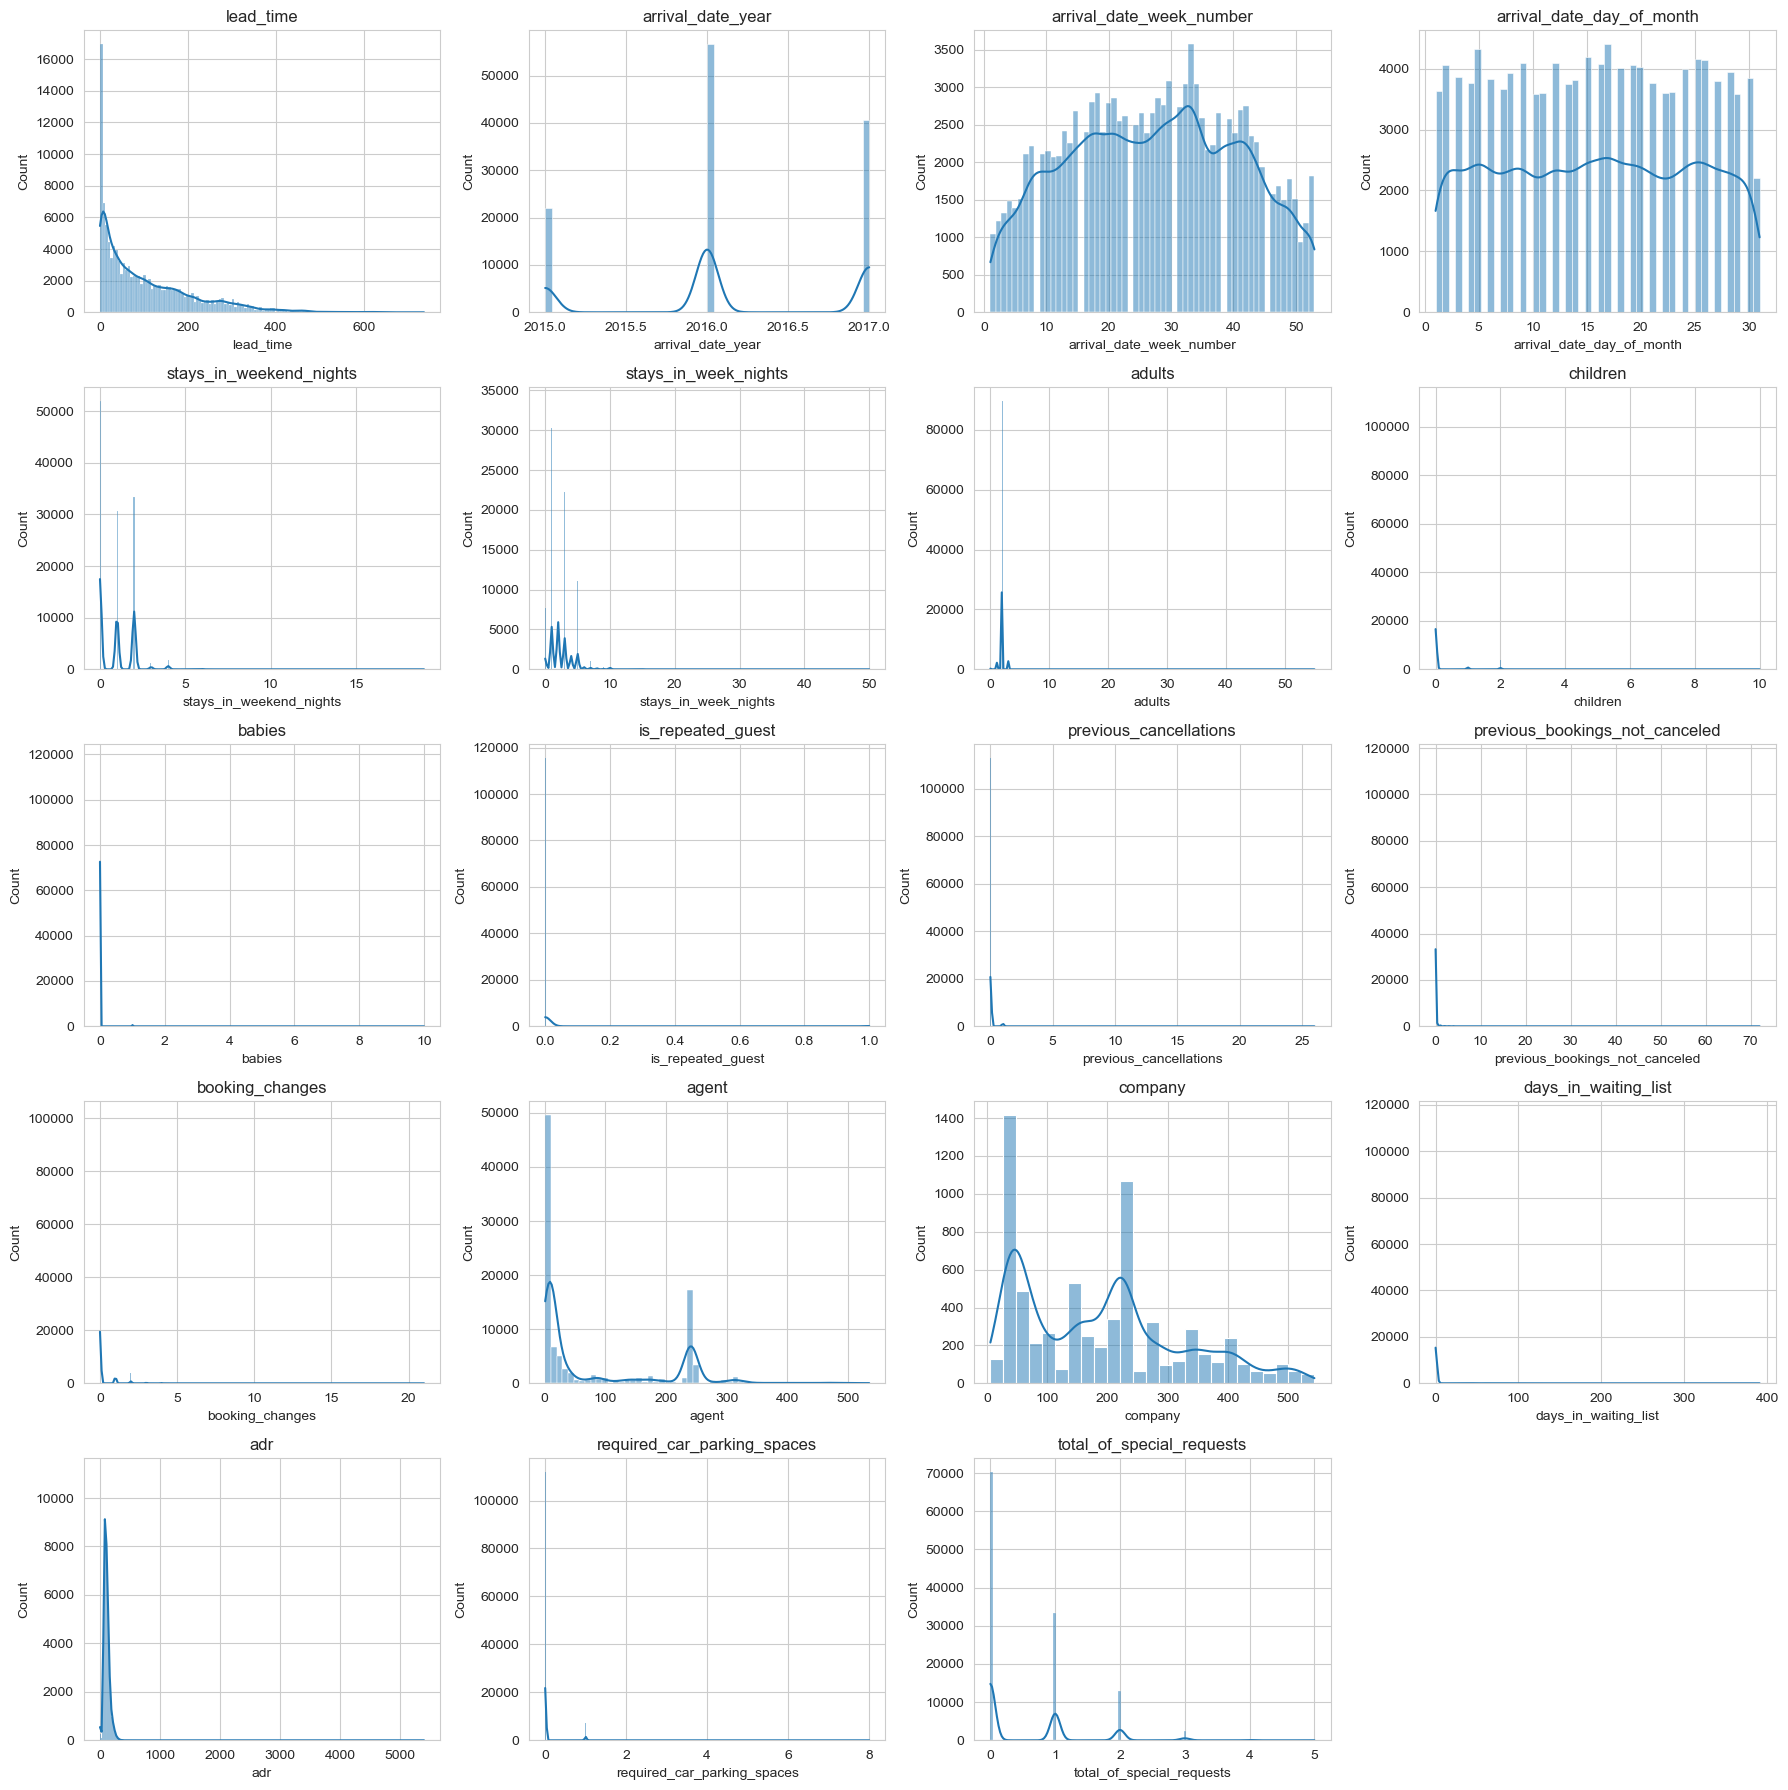

In [60]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('is_canceled')

fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interprétation

Les histogrammes montrent que la majorité des variables numériques ne suivent pas une distribution normale.

La variable `lead_time` présente une forte asymétrie positive : la plupart des réservations sont effectuées peu de temps avant l'arrivée, tandis qu'un faible nombre est réservé très longtemps à l'avance.

Les variables `stays_in_weekend_nights`, `stays_in_week_nights`, `children`, `babies`, `previous_cancellations`, `previous_bookings_not_canceled`, `booking_changes`, `days_in_waiting_list` et `required_car_parking_spaces` sont fortement concentrées autour de faibles valeurs, principalement 0, avec quelques observations beaucoup plus élevées.

La variable `adults` est principalement centrée autour de deux adultes par réservation, ce qui correspond au comportement attendu des clients.

Enfin, la variable `adr` présente une longue queue à droite, indiquant la présence de quelques réservations ayant un tarif journalier très élevé.

Ces distributions confirment que plusieurs variables sont asymétriques et contiennent des valeurs extrêmes qui devront être étudiées dans la section suivante.

### Décision

Les distributions observées serviront à orienter le prétraitement des données.

L'analyse des valeurs aberrantes permettra de déterminer si les observations extrêmes correspondent à des erreurs de données ou à des situations réelles qui devront être conservées dans le jeu de données.

# 5. Analyse des valeurs aberrantes (Outliers)

Les valeurs aberrantes (outliers) sont des observations qui s'éloignent fortement du comportement général des données. Elles peuvent résulter d'erreurs de saisie, de problèmes de mesure ou représenter des situations réelles mais rares.

Plusieurs méthodes permettent de les détecter :

- **Méthode de l'IQR (Interquartile Range)** : identifie les observations situées en dehors de l'intervalle \([Q1 - 1,5 × IQR ; Q3 + 1,5 × IQR]\).
- **Règle des 3 Sigma** : adaptée principalement aux données suivant une distribution normale.
- **Boxplot** : représentation graphique basée sur l'IQR permettant de visualiser rapidement les observations atypiques.

Étant donné que la majorité des variables numériques ne suivent pas une distribution normale, le **Boxplot basé sur l'IQR** a été retenu pour cette analyse.

In [61]:
num_cols = ['lead_time','stays_in_weekend_nights','stays_in_week_nights','adults',
            'children','babies','adr','booking_changes','days_in_waiting_list',
            'previous_cancellations','total_of_special_requests']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0


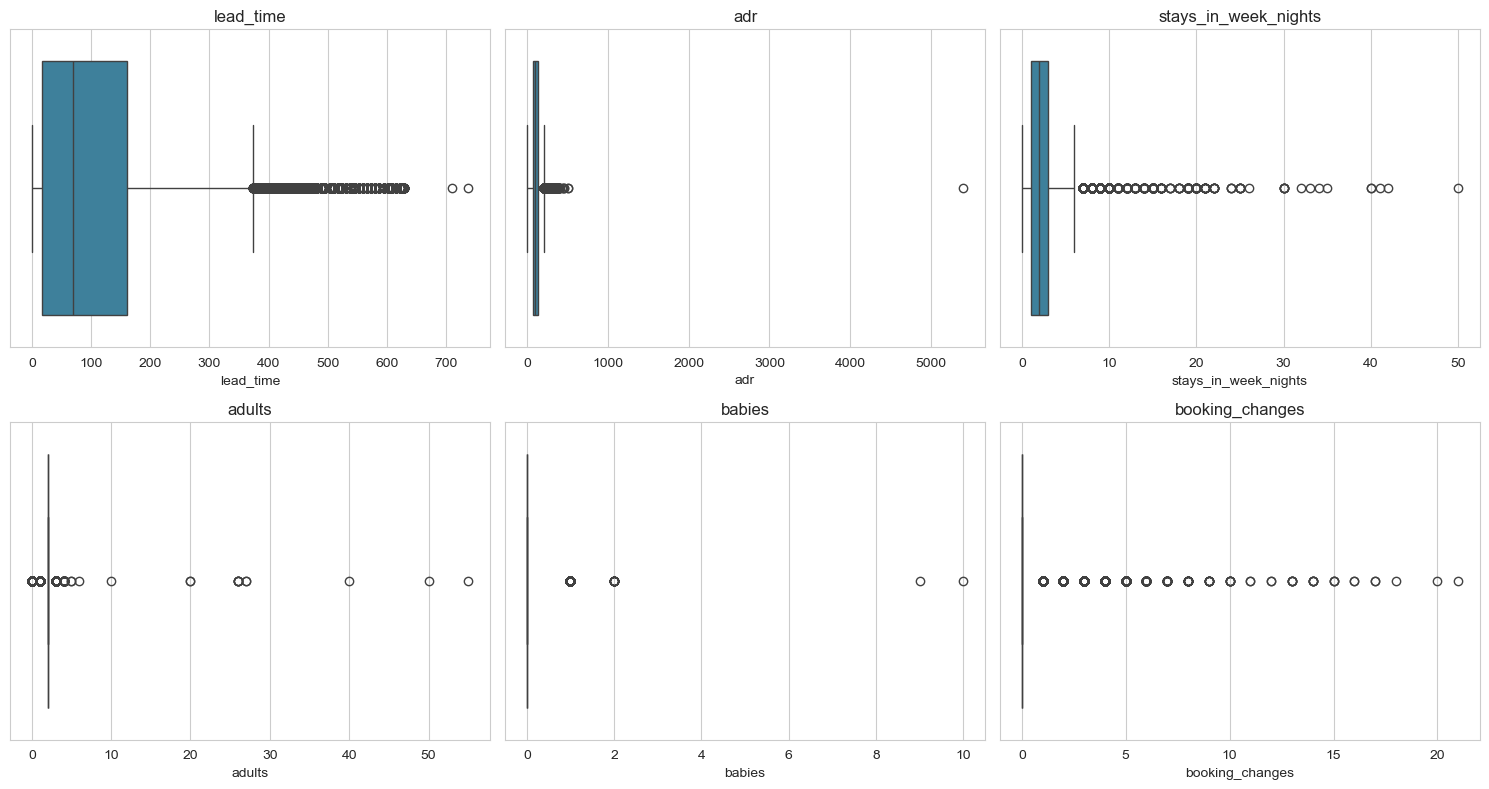

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
outlier_cols = ['lead_time','adr','stays_in_week_nights','adults','babies','booking_changes']
for ax, col in zip(axes.flat, outlier_cols):
    sns.boxplot(x=df[col], ax=ax, color='#2E86AB')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [63]:
anomalies = pd.DataFrame({
    "Anomalie": [
        "ADR négatif",
        "ADR > 1000",
        "Réservations sans occupant",
        "Lead time maximal"
    ],
    "Résultat": [
        f"{(df['adr'] < 0).sum()} ligne(s)",
        f"{(df['adr'] > 1000).sum()} ligne(s)",
        f"{((df['adults']==0) & (df['children'].fillna(0)==0) & (df['babies']==0)).sum()} réservations",
        f"{df['lead_time'].max()} jours"
    ]
})

display(anomalies)

,Anomalie,Résultat
0,ADR négatif,1 ligne(s)
1,ADR > 1000,1 ligne(s)
2,Réservations sans occupant,180 réservations
3,Lead time maximal,737 jours


### Interprétation

Les Boxplots confirment la présence de valeurs aberrantes dans plusieurs variables numériques.

La variable `adr` présente les observations les plus extrêmes, avec une valeur négative (-6,38) et une valeur maximale de 5400. Ces observations sont peu plausibles et pourraient correspondre à des erreurs de saisie ou à des anomalies de collecte.

La variable `lead_time` atteint jusqu'à 737 jours. Bien que cette valeur soit élevée, elle reste cohérente avec le domaine hôtelier puisqu'une réservation peut être effectuée plusieurs mois, voire près de deux ans à l'avance.

Les variables `stays_in_week_nights`, `adults`, `babies` et `booking_changes` présentent également des observations extrêmes. Certaines peuvent correspondre à des cas réels mais peu fréquents, tandis que d'autres devront être vérifiées lors du prétraitement.

Enfin, **180 réservations ne comportent aucun occupant** (0 adulte, 0 enfant et 0 bébé), ce qui constitue une incohérence métier nécessitant un traitement spécifique.

### Décision

Les valeurs aberrantes ne seront pas supprimées automatiquement.

Dans le Notebook 03 (Prétraitement), chaque variable sera analysée individuellement afin de distinguer les observations plausibles des anomalies. Les incohérences métier, comme les réservations sans occupant ou les valeurs manifestement erronées de `adr`, feront l'objet d'un traitement spécifique, tandis que les valeurs extrêmes réalistes seront conservées afin de préserver l'information utile pour les modèles prédictifs.

# 6 Corrélations (variables numériques vs cible)

L'analyse des corrélations permet d'étudier les relations linéaires entre les variables numériques ainsi qu'entre les variables explicatives (Xi) et la variable cible (`is_canceled`).

Les coefficients de corrélation de Pearson sont représentés sous forme de Heatmap afin d'identifier les variables les plus liées aux annulations et de détecter d'éventuelles redondances entre les variables numériques.

Il est important de rappeler qu'une corrélation élevée n'implique pas une relation de causalité.

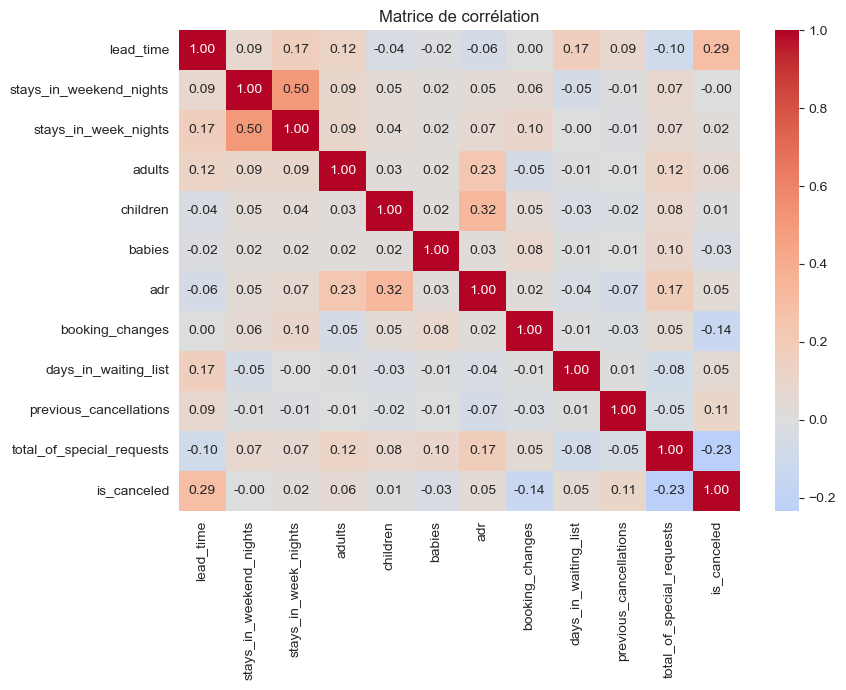

is_canceled                  1.000000
lead_time                    0.293123
previous_cancellations       0.110133
adults                       0.060017
days_in_waiting_list         0.054186
adr                          0.047557
stays_in_week_nights         0.024765
children                     0.005048
stays_in_weekend_nights     -0.001791
babies                      -0.032491
booking_changes             -0.144381
total_of_special_requests   -0.234658
Name: is_canceled, dtype: float64

In [64]:
corr_cols = num_cols + ['is_canceled']
corr = df[corr_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()
corr['is_canceled'].sort_values(ascending=False)

### Interprétation

La matrice de corrélation montre que les relations linéaires entre les variables numériques sont globalement faibles à modérées, ce qui indique une faible redondance entre les variables explicatives.

En ce qui concerne la variable cible `is_canceled`, la variable `lead_time` présente la corrélation positive la plus élevée (**r ≈ 0,29**). Cela suggère que les réservations effectuées longtemps à l'avance ont davantage tendance à être annulées.

Les variables `previous_cancellations` (**r ≈ 0,11**) et `adults` (**r ≈ 0,06**) présentent également une légère corrélation positive avec les annulations.

À l'inverse, `total_of_special_requests` présente une corrélation négative (**r ≈ -0,23**), ce qui indique que les clients ayant formulé davantage de demandes spéciales semblent moins susceptibles d'annuler leur réservation.

Enfin, on observe une corrélation modérée entre `stays_in_weekend_nights` et `stays_in_week_nights` (**r ≈ 0,50**), ce qui est logique puisque ces deux variables décrivent la durée du séjour.

### Décision

Les variables présentant les corrélations les plus importantes avec la variable cible seront conservées pour la phase de modélisation.

Toutefois, la corrélation de Pearson mesure uniquement les relations linéaires. Une faible corrélation ne signifie donc pas qu'une variable est inutile, car certains modèles de Machine Learning (arbres de décision, Random Forest, XGBoost, etc.) sont capables d'exploiter des relations non linéaires.

La sélection finale des variables sera réalisée dans le Notebook 03 en combinant les connaissances métier, les résultats de cette analyse et des méthodes de sélection de variables.

# 7 Distribution de la cible

La variable cible `is_canceled` représente le statut final d'une réservation :

- **0** : réservation maintenue ;
- **1** : réservation annulée.

L'analyse de sa distribution permet de vérifier si le jeu de données est équilibré ou non. Un déséquilibre important pourrait influencer l'apprentissage des modèles de classification et nécessiter des techniques de rééquilibrage.

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


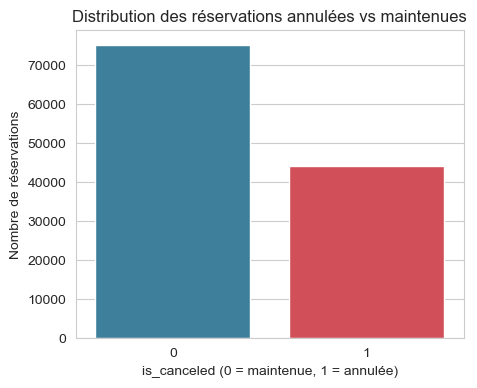

In [65]:
cancel_counts = df['is_canceled'].value_counts()
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(cancel_counts)
print(cancel_pct.round(2))

plt.figure(figsize=(5,4))
sns.countplot(
    x='is_canceled',
    data=df,
    hue='is_canceled',
    palette=['#2E86AB', '#E63946'],
    legend=False
)
plt.title("Distribution des réservations annulées vs maintenues")
plt.xlabel("is_canceled (0 = maintenue, 1 = annulée)")
plt.ylabel("Nombre de réservations")
plt.show()


### Interprétation

La variable cible présente **75 166 réservations maintenues (62,96 %)** contre **44 224 réservations annulées (37,04 %)**.

Le jeu de données présente donc un **déséquilibre modéré** entre les deux classes. La classe majoritaire correspond aux réservations maintenues, mais la classe des annulations reste suffisamment représentée pour permettre l'apprentissage des modèles de classification.

Ce déséquilibre n'est pas suffisamment important pour conclure immédiatement à la nécessité d'un rééquilibrage. Il conviendra toutefois d'en tenir compte lors de l'évaluation des modèles en utilisant des métriques adaptées.

### Décision

Aucune technique de rééquilibrage ne sera appliquée durant l'EDA.

Lors du développement des modèles, les performances seront évaluées à l'aide de plusieurs métriques (Accuracy, Precision, Recall, F1-score et ROC-AUC). Si un biais en faveur de la classe majoritaire est observé, des techniques comme `class_weight='balanced'`, le suréchantillonnage (SMOTE) ou le sous-échantillonnage pourront être testées et comparées.

# 8 Typologie des variables

L'identification du type de chaque variable est une étape essentielle avant le prétraitement.

Selon leur nature (numérique, catégorielle nominale ou catégorielle ordinale), les variables nécessiteront des traitements différents, notamment pour l'encodage utilisé par les modèles de Machine Learning.

In [66]:
# Variables numériques
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Variables catégorielles
cat_vars = df.select_dtypes(include=['object']).columns.tolist()

print("Variables numériques :", num_vars)
print("\nVariables catégorielles :", cat_vars)

Variables numériques : ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Variables catégorielles : ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


In [67]:
typologie = pd.DataFrame({
    "Type": [
        "Numériques",
        "Catégorielles nominales",
        "Catégorielles ordinales"
    ],
    "Variables": [
        ", ".join([
            'lead_time','arrival_date_year','arrival_date_week_number',
            'arrival_date_day_of_month','stays_in_weekend_nights',
            'stays_in_week_nights','adults','children','babies',
            'previous_cancellations','previous_bookings_not_canceled',
            'booking_changes','agent','company','days_in_waiting_list',
            'adr','required_car_parking_spaces',
            'total_of_special_requests'
        ]),
        ", ".join([
            'hotel','meal','country','market_segment',
            'distribution_channel','reserved_room_type',
            'assigned_room_type','customer_type','agent','company'
        ]),
        ", ".join([
            'deposit_type',
            'reservation_status'
        ])
    ]
})

display(typologie)

,Type,Variables
0,Numériques,"lead_time, arrival_date_year, arrival_date_wee..."
1,Catégorielles nominales,"hotel, meal, country, market_segment, distribu..."
2,Catégorielles ordinales,"deposit_type, reservation_status"


### Interprétation

Le jeu de données contient des variables numériques ainsi que des variables catégorielles nominales et ordinales.

Les variables catégorielles devront être encodées avant l'entraînement des modèles. Les variables nominales seront traitées différemment des variables ordinales afin de préserver leur signification.

Par ailleurs, les variables `reservation_status` et `reservation_status_date` nécessitent une attention particulière. Elles contiennent des informations connues uniquement après l'issue de la réservation et sont directement liées à la variable cible `is_canceled`. Leur utilisation comme variables explicatives introduirait un risque de **Data Leakage** (fuite d'information), susceptible de fausser les performances des modèles prédictifs.

### Décision

Les variables numériques et catégorielles seront préparées selon leur nature lors du Notebook **NB_03_Pretraitement**.

Les variables `reservation_status` et `reservation_status_date` seront analysées puis supprimées au cours du prétraitement afin d'éviter toute fuite d'information (Data Leakage) lors de l'entraînement des modèles.

# 9. Synthèse de l'analyse exploratoire (EDA)

| Constat | Détail |
|---|---|
| Distribution de la variable cible | 62,96 % de réservations maintenues / 37,04 % de réservations annulées (déséquilibre modéré) |
| Valeurs manquantes | `company` (94,31 %), `agent` (13,69 %), `country` (0,41 %), `children` (~0 %) |
| Doublons | Environ 27 % des lignes sont dupliquées |
| Valeurs aberrantes | `adr` négatif (-6,38) et valeur extrême (5400), 180 réservations sans occupant |
| Risque de Data Leakage | `reservation_status`, `reservation_status_date` |
| Variables à forte cardinalité | `country`, `agent`, `company` |
| Variables les plus liées à la cible | `lead_time` (corrélation positive), `total_of_special_requests` (corrélation négative) |


## Problèmes identifiés (à traiter dans NB_03_Pretraitement)

1. Traitement des valeurs manquantes selon leur nature et leur importance.
2. Suppression des variables présentant un risque de Data Leakage (`reservation_status` et `reservation_status_date`).
3. Traitement des valeurs aberrantes et des incohérences métier (par exemple les réservations sans occupant).
4. Encodage des variables catégorielles selon leur type (nominal ou ordinal).
5. Gestion des variables à forte cardinalité (`country`, `agent`, `company`).
6. Transformation et mise à l'échelle des variables numériques si nécessaire.
7. Vérification de l'impact du déséquilibre modéré de la variable cible lors de l'entraînement et de l'évaluation des modèles.



# 10. Conclusion

L'analyse exploratoire a permis de mieux comprendre la structure et la qualité du jeu de données avant toute phase de modélisation.

Les principales problématiques identifiées concernent les valeurs manquantes, les valeurs aberrantes, les doublons, les variables à forte cardinalité ainsi que le risque de fuite d'information (Data Leakage).

L'étude des distributions, des corrélations et de la variable cible a également permis d'identifier plusieurs variables susceptibles d'influencer les annulations, notamment `lead_time` et `total_of_special_requests`.

Les décisions prises au cours de cette analyse serviront directement de base au Notebook **NB_03_Pretraitement**, dans lequel seront appliqués les traitements de nettoyage, de transformation, d'imputation, d'encodage et de sélection des variables avant l'entraînement des modèles prédictifs.